### Disclaimer : we'll only work with the onset state as target (s=1), and set the s=2 as 0


In [1]:
import numpy as np
import pandas as pd
from hmmlearn import hmm
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import ConfusionMatrixDisplay as plot_cm
import matplotlib.pyplot as plt
import datetime as dt
import sys
from scipy.signal import medfilt
from pathlib import Path
sys.path.append(f"{Path.home()}/pavnet-v3/vlfcode/")
#sys.path.append("/home/aldo/maestria/tesis/vlf/code/")
from sxrf_download import sunpy_xrf
from sklearn.metrics import classification_report, confusion_matrix
from scipy import signal
#xr_df = sunpy_xrf("2025-01-1 12:00", "2025-08-26 21:59", sat_number=18)
import hmmlearn
import modelutils as mu 
from statsmodels.tsa.regime_switching.markov_autoregression import MarkovAutoregression as mar



In [2]:


# df = pd.read_csv(...) 
df1 = pd.read_csv("vlf_trainingdata_2025_piu.csv", index_col=[0],parse_dates=[0])
df2 = pd.read_csv("vlf_test_2026_piu.csv", index_col=[0],parse_dates=[0])
#df2.rename(columns={"GOES-18_long": "GOES18"}, inplace=True)
df2.drop(columns=["GOES-18_long"], inplace=True)
#df2.columns = [ "NAA","GOES18" ,"state" ,"GOES19", "flare_class"]
_df2 = df2[ ["NAA","GOES18" ,"state" ,"GOES19"]]
_df1 = df1[ ["NAA","GOES18" ,"state" ,"GOES19"]]
#df = df1.join(df2[[ "NAA","GOES18" ,"GOES18" ,"state" ,"GOES19"]], how="left")
# Drop duplicate rows within each DataFrame (keep first occurrence per timestamp)
_df1 = _df1[~_df1.index.duplicated(keep='first')]
_df2 = _df2[~_df2.index.duplicated(keep='first')]

# Now concatenate and drop duplicates across the combined set
combined = pd.concat([_df1, _df2])
df = combined[~combined.index.duplicated(keep='first')]  # or keep='last'
# set state decay (2) as normal (0)
#df.loc[df["state"]==2, "state"] = 0

In [3]:
df.columns

Index(['NAA', 'GOES18', 'state', 'GOES19'], dtype='str')

In [4]:
lowp = signal.firwin(101, 0.01, fs=1/10)
df[f"NAA-filt"] = signal.filtfilt(lowp, 1, df["NAA"].values)
#df['NAA_dB'] = 20 * np.log10(df['NAA-filt'] + 1e-9)
# derivada o velocidad de cambio

df.head()

df.loc[:, 'NAA'] = df['NAA'].clip(lower=-10)
background = df['NAA'].rolling(window=60, center=False).min()
df["NAA_dB_bgrm"] = df["NAA"]-background #brackground removed
df['Delta'] = df['NAA'].diff(5).fillna(0)

In [5]:
df2.columns

Index(['NAA', 'GOES18', 'state', 'GOES19', 'flare_class'], dtype='str')

In [6]:

df["time"] = df.index.time
df["date"] = df.index.date
pivotdf = df.pivot(values="NAA", columns="time", index="date")#.dropna()
pivot_qdc = pivotdf.rolling(window=27, center=False, min_periods=2).median()
# removing the QDC  mask
qdc_refcurve = pivot_qdc.unstack().swaplevel().sort_index()
qdc_refcurve.index = [dt.datetime.combine(qdc_refcurve.index[i][0], qdc_refcurve.index[i][1]) for i in range(len(qdc_refcurve))]
df["qdc_ref"] = qdc_refcurve
# Actualizacion: cambio de X, X= [delta(background removed) , diff(periods=5)]
df["delta_amp"] = df["NAA"] - df["qdc_ref"]
df['diff_amp'] = df['delta_amp'].diff(5).fillna(0)




In [7]:
amp = df["delta_amp"]

# Multi-scale slopes
# df["slope_1m"]  = amp.diff(6)          # 1 min
df["slope_5m"]  = amp.diff(5)         # 5 min
df["slope_10m"] = amp.diff(10)         # 15 min

# Local "transient" feature: how far is the current sample from its 30-min median
df["transient"] = amp - amp.rolling(180, center=False, min_periods=60).median()

# Rolling volatility (onsets increase high-frequency power)
df["rv_5m"] = amp.rolling(30).std()

In [8]:
from scipy.signal import butter, filtfilt
b, a = butter(4, [1/(30), 1/(3)], btype='band', fs=1/1)  # 3–30 min band
df["bp_energy"] = filtfilt(b, a, df["delta_amp"].fillna(0))**2

In [9]:
f = lambda x:x+2
f(8)

10

In [10]:

# %matplotlib qt

In [11]:
# get transient
f_transient = lambda amp: amp - amp.rolling(180, center=False, min_periods=60).median() 

# local background
# 60 min
win         = "60min"
min_periods = 20
df["bg_local_60min"] = (
    df["NAA"]
        .rolling(win, center=False, min_periods=min_periods)
        .median()
)
df["bg_local_60min"] = df["bg_local_60min"].fillna(df["qdc_ref"])
df["delta60min_amp_local"] = df["NAA"] - df["bg_local_60min"]
df["diff60min_amp_local"] = df["delta60min_amp_local"].diff(5).fillna(0)
df["transient_60"] = f_transient(df["delta60min_amp_local"])#amp - amp.rolling(180, center=False, min_periods=60).median()
# 120 min
win         = "120min"
min_periods = 20
df["bg_local_120min"] = (
    df["NAA"]
        .rolling(win, center=False, min_periods=min_periods)
        .median()
)
df["bg_local_120min"] = df["bg_local_120min"].fillna(df["qdc_ref"])
df["delta120min_amp_local"] = df["NAA"] - df["bg_local_120min"]
df["diff120min_amp_local"] = df["delta120min_amp_local"].diff(5).fillna(0)

# df["transient_120"] = amp - amp.rolling(180, center=False, min_periods=60).median()
df["transient_120"] = f_transient(df["delta120min_amp_local"])

Text(0, 0.5, 'X Ray Flux')

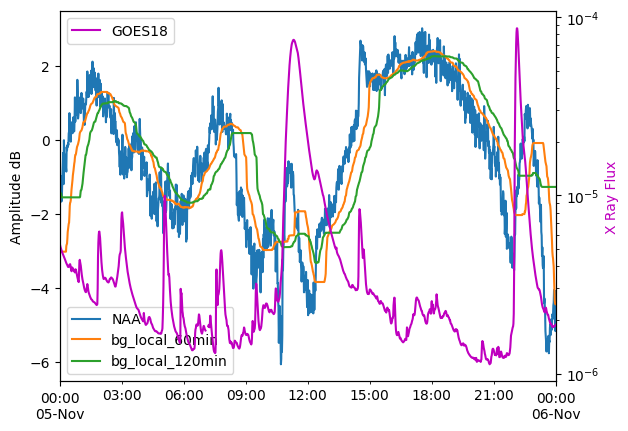

In [22]:

df_ = df.loc[dt.datetime(2025,11,5):dt.datetime(2025,11,6)]
fig=plt.figure()
ax=plt.subplot()
df_[["NAA", "bg_local_60min", "bg_local_120min"]].plot(ax=ax)
ax.set_ylabel("Amplitude dB")
ax2 = ax.twinx()
df_[["GOES18"]].plot(color="m",ax=ax2)
ax2.set_yscale("log")
ax2.set_ylabel("X Ray Flux", color="m")

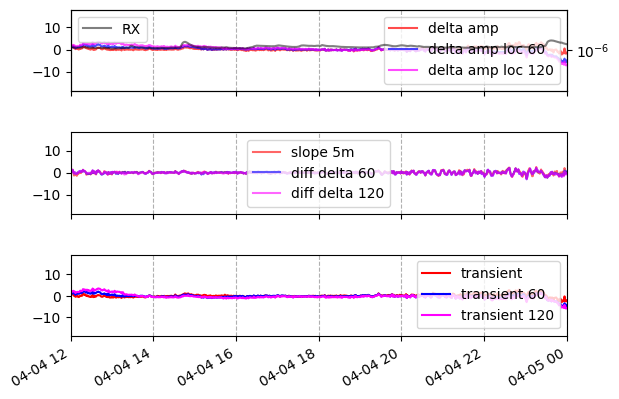

In [12]:
# plot

# %matplotlib qt
fig = plt.figure()
ax = plt.subplot(311)
ax.plot(df["delta_amp"], label="delta amp", color="red", alpha=0.7)
ax.plot(df["delta60min_amp_local"], label="delta amp loc 60", color="blue", alpha=0.7)
ax.plot(df["delta120min_amp_local"], label="delta amp loc 120", color="magenta", alpha=0.7)
ax2 = ax.twinx()
ax2.plot(df["GOES18"], label="RX", color="k", alpha=.5)
ax2.set_yscale("log")
ax.legend(); ax2.legend()
ax.grid(axis="x", ls="--")
ax = plt.subplot(312, sharex=ax)
ax.plot(df["slope_5m"], color="red", label="slope 5m", alpha=.6)
# ax.plot(df["slope_10m"], label="slope 5m", alpha=.6)
ax.plot(df["diff60min_amp_local"],color = "blue", label="diff delta 60", alpha=.6)
ax.plot(df["diff120min_amp_local"], color="magenta", label="diff delta 120", alpha=.6)
ax.legend();
ax.grid(axis="x", ls="--")
ax = plt.subplot(313, sharex=ax)
ax.plot(df["transient"], color="r",label="transient")
ax.plot(df["transient_60"], color="blue", label="transient 60")
ax.plot(df["transient_120"], color="magenta", label="transient 120")
ax.legend()
ax.grid(axis="x", ls="--")
# ax = plt.subplot(414, sharex=ax)
# ax.plot(df["bp_energy"], label="bp_energy")
# ax.legend()
# ax.grid(axis="x", ls="--")
# ax.set_yscale("log")
ax.set_xlim(dt.datetime(2025, 4, 4,12), dt.datetime(2025, 4, 5))
fig.autofmt_xdate()
plt.subplots_adjust(hspace=0.5)
plt.show()

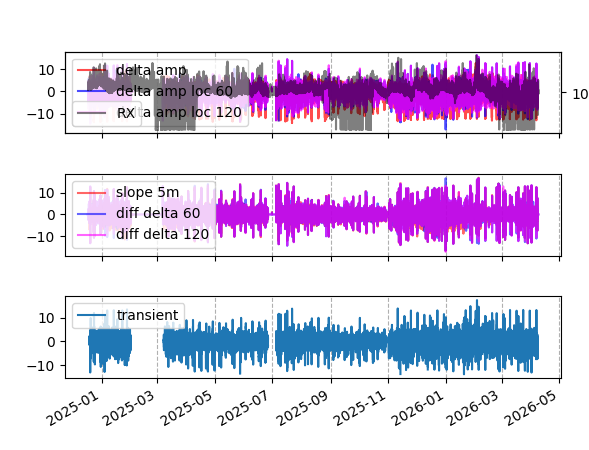

In [ ]:
# plt.figure()
# df["diff60min_amp_local"].plot()
sum(df["diff60min_amp_local"]  == df["diff120min_amp_local"]) , sum(df["diff60min_amp_local"]  != df["diff120min_amp_local"]) 

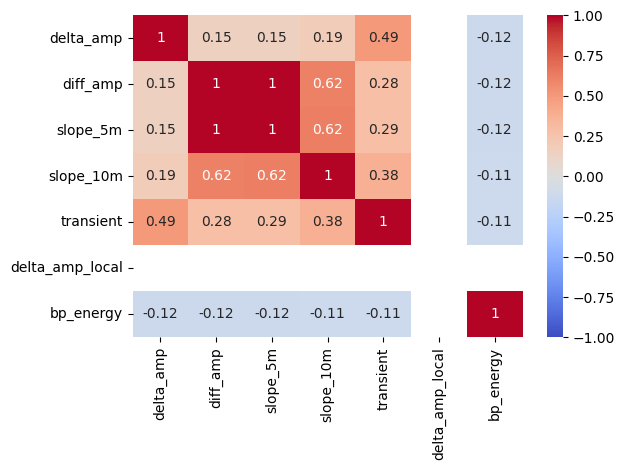

In [23]:
%matplotlib inline
import seaborn as sns
feat_names=["delta_amp", "diff_amp", "slope_5m", "slope_10m", "transient",  "delta_amp_local","bp_energy"]

corr = pd.DataFrame(df, columns=feat_names).corr()
fig = plt.figure()
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm")
plt.tight_layout()

<Axes: >

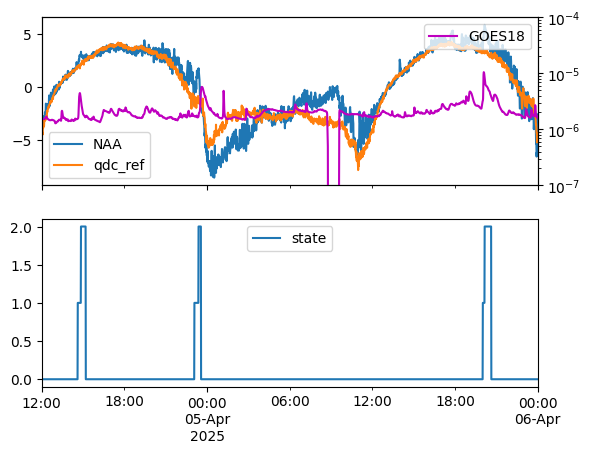

In [29]:
dl1,dl2 = dt.datetime(2025,4,4,12), dt.datetime(2025,4,6)
#df[["delta_amp","diff_amp"]].plot()
fig, axs = plt.subplots(2,1,sharex=True)
ax=axs[0]

df.loc[dl1:dl2, ["NAA","qdc_ref"]].plot(ax=ax)
ax2 = ax.twinx()
df[["GOES18"]].plot(color="m",ax=ax2)
ax2.set_yscale("log")
ax2.set_ylim(1e-7, 1e-4)
# plt.xlim(dl1, dl2)
ax=axs[1]

df.loc[dl1:dl2, ["state"]].plot(ax=ax)
# plt.xlim(dl1, dl2)
#plt.axvspan(rx_suntimes[dl1.date][0], color="yellow")
#plt.axvspan(*rx_suntimes[(dl2-dt.timedelta(days=1)).date()], color="yellow")

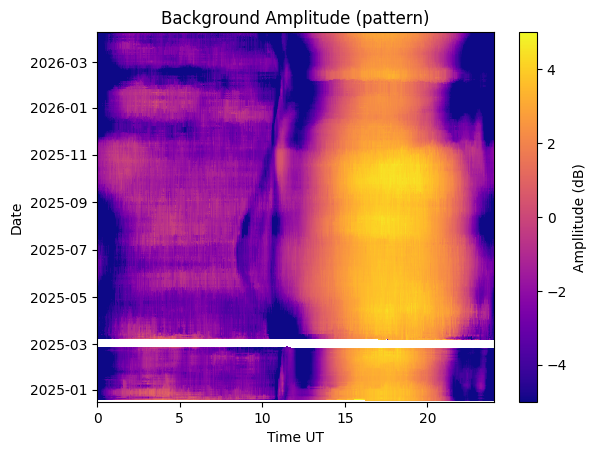

In [30]:

time_arr = np.linspace(0,24, len(pivot_qdc.columns))

fig, ax = plt.subplots()
im = ax.pcolormesh(time_arr, pivot_qdc.index, pivot_qdc.values, cmap="plasma", vmin=-5,vmax=5)
ax.set_xlabel("Time UT")
ax.set_ylabel("Date")
cb = fig.colorbar(im, ax=ax)
cb.set_label("Ampllitude (dB)")
ax.set_title("Background Amplitude (pattern)")
plt.show()



## Using ony diurnal times
based on the astronomical sunrise and sunset


In [31]:
import astropy.units as u
from astropy.coordinates import EarthLocation, AltAz, get_sun
from astropy.time import Time

# Define observer locations
loc_tx = EarthLocation(lat=44.63678 * u.deg, lon=-67.27949 * u.deg)
loc_rx = EarthLocation(lat=-12.50423 * u.deg, lon=-76.79773 * u.deg)

# Solar elevation target angle:
#  -0.833° for standard horizon sunrise/sunset (includes atmospheric refraction)
# -18.000° for astronomical twilight (dawn/dusk)
TARGET_ALT = -0.833 


def get_sun_events(d, location, target_alt=-0.833):
    """Calculates event crossing times in UTC decimal hours using Astropy."""
    date_str = str(d)[:10]
    t0 = Time(f"{date_str} 00:00:00", scale="utc")
    times = t0 + np.linspace(0, 24, 1440) * u.hour  # 1-minute grid

    # Compute solar altitudes
    alts = (
        get_sun(times)
        .transform_to(AltAz(obstime=times, location=location))
        .alt.deg
    )
    diff = alts - target_alt

    # Detect zero-crossings
    sign_change = np.diff(np.sign(diff))
    rising_idx = np.where(sign_change > 0)[0]
    setting_idx = np.where(sign_change < 0)[0]

    return interpolate_hour(diff, rising_idx), interpolate_hour(diff, setting_idx)

def interpolate_hour(diff,idx_list):
    if len(idx_list) == 0:
        return np.nan  # Returns NaN if event doesn't occur (e.g., persistent twilight)
    i = idx_list[0]
    y0, y1 = diff[i], diff[i + 1]
    frac = -y0 / (y1 - y0)
    return (i + frac) * (24.0 / 1440.0)

# Execute loop
tx_sunrise, tx_sunset = [], []
rx_sunrise, rx_sunset = [], []
tx_suntimes = {}
rx_suntimes = {}

for d in pivot_qdc.index:
    print(f"{d}", end="\r")
    # Transmitter (TX - Maine)
    t0_tx, t1_tx = get_sun_events(d, loc_tx, target_alt=TARGET_ALT)
    tx_sunrise.append(t0_tx)
    tx_sunset.append(t1_tx)
    tx_suntimes[d] = [t0_tx, t1_tx]

    # Receiver (RX - Lima)
    t0_rx, t1_rx = get_sun_events(d, loc_rx, target_alt=TARGET_ALT)
    rx_sunrise.append(t0_rx)
    rx_sunset.append(t1_rx)
    rx_suntimes[d] = [t0_rx, t1_rx]

2026-04-08

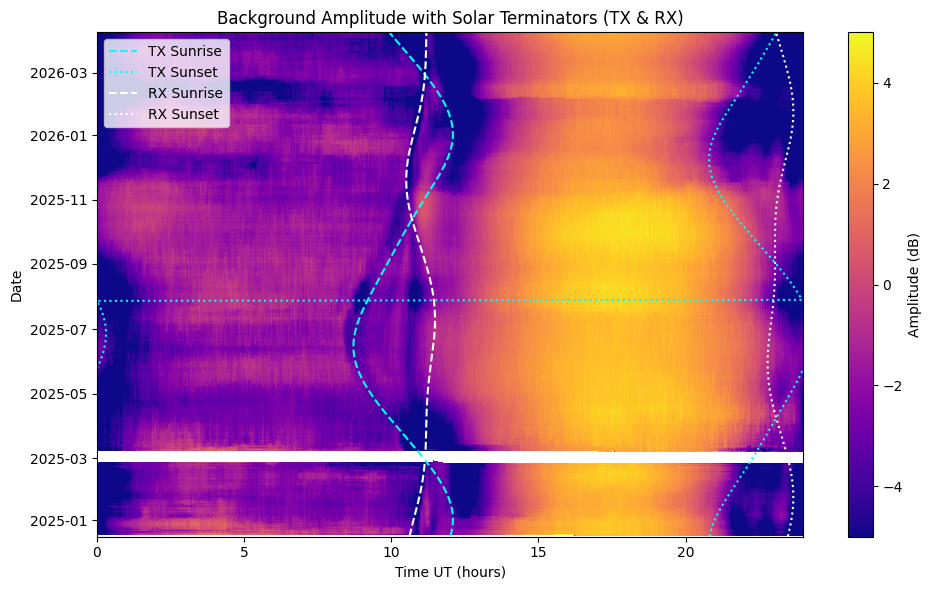

In [32]:
fig, ax = plt.subplots(figsize=(10, 6))

# Mapa de calor de amplitud
im = ax.pcolormesh(time_arr, pivot_qdc.index, pivot_qdc.values, cmap="plasma", vmin=-5, vmax=5)

# Curvas de Amanecer/Atardecer para TX y RX (X: hora decimal UT, Y: fechas)
ax.plot(tx_sunrise, pivot_qdc.index, color='cyan', linestyle='--', linewidth=1.5, label='TX Sunrise')
ax.plot(tx_sunset,  pivot_qdc.index, color='cyan', linestyle=':',  linewidth=1.5, label='TX Sunset')

ax.plot(rx_sunrise, pivot_qdc.index, color='white', linestyle='--', linewidth=1.5, label='RX Sunrise')
ax.plot(rx_sunset,  pivot_qdc.index, color='white', linestyle=':',  linewidth=1.5, label='RX Sunset')

# Formatos y etiquetas
ax.set_xlabel("Time UT (hours)")
ax.set_ylabel("Date")
ax.set_title("Background Amplitude with Solar Terminators (TX & RX)")
ax.set_xlim(0, 24)
ax.legend(loc='upper left', framealpha=0.8)

cb = fig.colorbar(im, ax=ax)
cb.set_label("Amplitude (dB)")

plt.tight_layout()
plt.show()

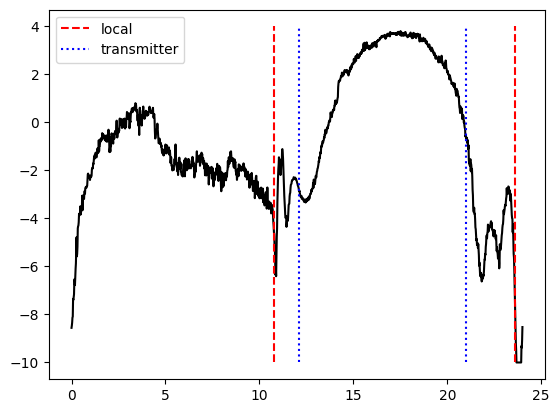

In [33]:
plt.figure()
plt.plot(time_arr, pivot_qdc.loc[dt.date(2025, 1, 1 ),:], color="k")
plt.vlines(rx_suntimes[dt.date(2025, 1, 1 )],-10,4, ls="--", color="red", label="local")
plt.vlines(tx_suntimes[dt.date(2025, 1, 1 )],-10,4, ls=":", color="blue", label="transmitter")
plt.legend()

In [ ]:

# 1. Extraer fechas y convertir la hora del index a hora decimal (UT)
fechas = df.index.date
horas = df.index.hour + df.index.minute / 60.0 + df.index.second / 3600.0

# 2. Mapear t0 (sunrise) y t1 (sunset) para cada fila del DataFrame
t0_vals = np.array([max([rx_suntimes[d][0], tx_suntimes[d][0]]) if d in rx_suntimes else np.nan for d in fechas])
t1_vals = np.array([max([rx_suntimes[d][1], tx_suntimes[d][1]]) if d in rx_suntimes else np.nan for d in fechas])

# 3. MÁSCARA BOOLEANA (True = Día, False = Noche)
mask_diurna = (horas >= t0_vals) & (horas <= t1_vals)

In [17]:
df_diurno = df[mask_diurna]


In [28]:
%matplotlib inline

(np.float64(20304.416666666668), np.float64(20305.0))

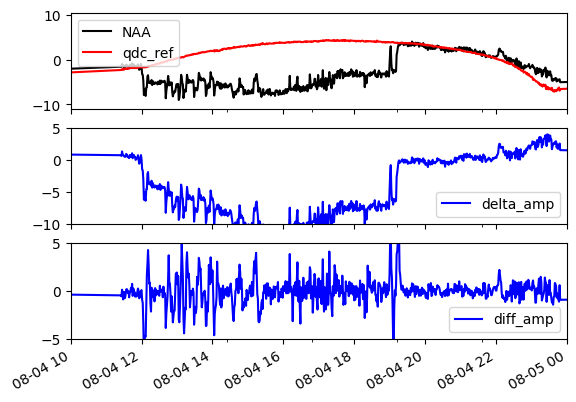

In [18]:
dl1,dl2 = dt.datetime(2025,8,4, 10), dt.datetime(2025,8,5)
#df[["delta_amp","diff_amp"]].plot()
fig = plt.figure()
ax = plt.subplot(311)
df_diurno[["NAA","qdc_ref"]].plot(color=["black", "red"], ax=ax)
#ax2 = ax.twinx()
#ax2.plot(df["GOES18"], color="purple")
#ax2.set_ylim(1e-7, 1e-3)
ax = plt.subplot(312, sharex=ax)
df_diurno[["delta_amp"]].plot(color=["blue"], ax=ax)
ax.set_ylim(-10,5)
ax = plt.subplot(313, sharex=ax)
df_diurno[["diff_amp"]].plot(color=["blue"], ax=ax)
ax.set_ylim(-5,5)
plt.xlim(dl1, dl2)


<Axes: ylabel='Frequency'>

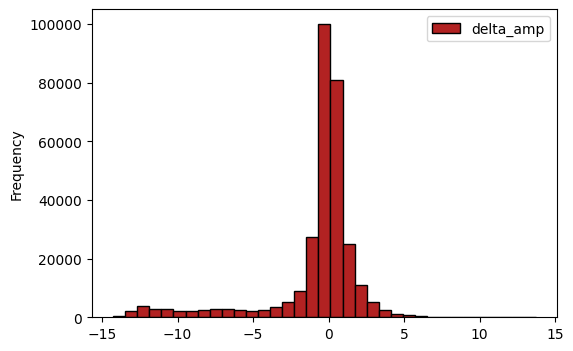

In [19]:
fig, ax = plt.subplots(figsize=(6,4))
# df_diurno[["delta_amp"]].plot(kind ="box", color="b", ax=ax,)
df_diurno[["delta_amp"]].plot(kind ="hist", color="firebrick", ax=ax,bins=35, edgecolor="k")

9

 delta_amp
values of bins: [1.6400e+02 6.5100e+02 1.7790e+03 2.7670e+03 2.1290e+03 1.9760e+03
 1.9420e+03 1.5660e+03 1.5050e+03 1.5440e+03 1.6410e+03 1.8630e+03
 1.9390e+03 1.9390e+03 1.7570e+03 1.6460e+03 1.6130e+03 1.6770e+03
 1.9410e+03 2.5320e+03 3.4250e+03 4.7490e+03 7.3730e+03 1.6960e+04
 4.3570e+04 8.7861e+04 5.4100e+04 2.2611e+04 1.0876e+04 6.8040e+03
 3.9760e+03 2.3350e+03 1.3670e+03 8.2100e+02 5.8900e+02 3.9700e+02
 2.6300e+02 1.8700e+02 1.1700e+02 4.9000e+01 3.7000e+01 4.0000e+01
 3.0000e+01 1.9000e+01 1.3000e+01 1.3000e+01 1.0000e+01 7.0000e+00
 4.0000e+00 8.0000e+00]
bins: [-14.26888631 -13.70916684 -13.14944737 -12.5897279  -12.03000843
 -11.47028896 -10.91056949 -10.35085002  -9.79113055  -9.23141108
  -8.67169161  -8.11197214  -7.55225267  -6.9925332   -6.43281373
  -5.87309426  -5.3133748   -4.75365533  -4.19393586  -3.63421639
  -3.07449692  -2.51477745  -1.95505798  -1.39533851  -0.83561904
  -0.27589957   0.2838199    0.84353937   1.40325884   1.96297831
   2.522

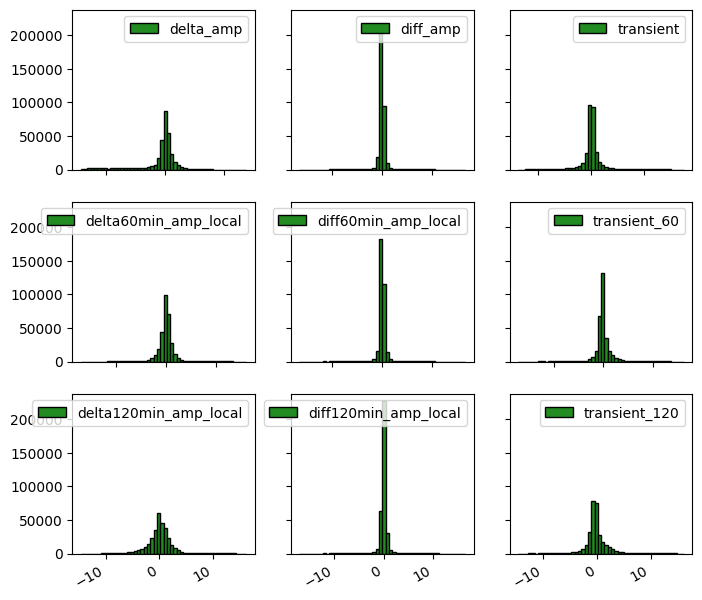

In [59]:
df_diurno.columns
features_ = ['delta_amp', 'diff_amp', 'transient', 'delta60min_amp_local', 'diff60min_amp_local', 'transient_60',
        'delta120min_amp_local', 'diff120min_amp_local', 'transient_120']
print(len(features_))
fig, axs = plt.subplots(3,3, sharey=True,figsize=(8,8))#sharex=True)

for r, rax in enumerate(axs):
    for c, ax in enumerate(rax):
        ii = 3*r+c
        f = features_[ii]
        n, b, p = ax.hist(df_diurno[f],bins=50, color="forestgreen", edgecolor="k", label=f)
        print("\n",f)
        print(f"values of bins: {n}")
        print(f"bins: {b}")
        print("-"*10)
        ax.legend(loc="upper right")
fig.autofmt_xdate()


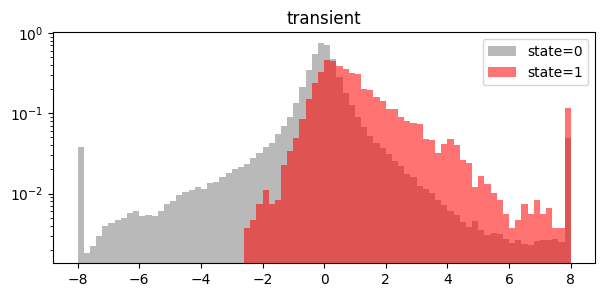

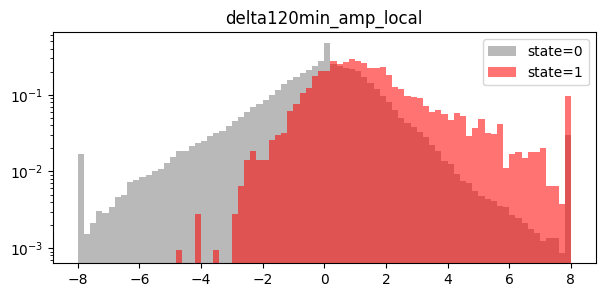

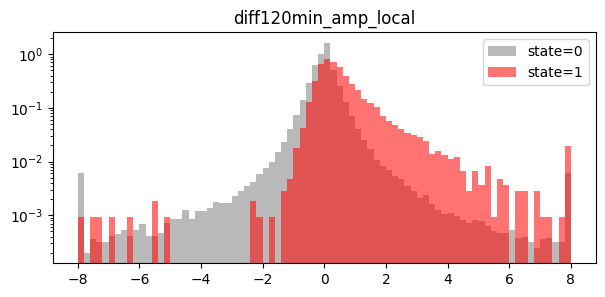

In [60]:
features = ["transient", "delta120min_amp_local", "diff120min_amp_local"]
bins = np.linspace(-8, 8, 81)

for f in features:
    fig, ax = plt.subplots(figsize=(7,3))
    for s, color in [(0, "gray"), (1, "red")]:
        mask = df_diurno["state"] == s
        n, b, p = ax.hist(df_diurno.loc[mask, f].clip(-8, 8),
                bins=bins, alpha=0.55, density=True,
                color=color, label=f"state={s}")
    ax.set_yscale("log")
    ax.set_title(f)
    ax.legend()
    plt.show()

In [42]:
_states = df["state"].values

onset_duration = df.index[np.pad(np.diff((_states==1.0)/1),(1, 0))==-1] - df.index[np.pad(np.diff((_states==1.0)/1),(1, 0))==1]
onset_duration = onset_duration.astype('timedelta64[s]')/np.timedelta64(60,"s" )
onset_duration

decay_duration = df.index[np.pad(np.diff((_states==2.0)/1),(1, 0))==-1] - df.index[np.pad(np.diff((_states==2.0)/1),(1, 0))==1]
decay_duration = decay_duration.astype('timedelta64[s]')/np.timedelta64(60,"s" )
decay_duration
# for l in zip(df_diurno.index[np.pad(np.diff(_states),(1, 0))==1] , df_diurno.index[np.pad(np.diff(_states),(1, 0))==-1]):
#     print(l)

Index([23.0, 26.0, 15.0, 54.0, 29.0, 37.0, 42.0, 22.0, 19.0, 31.0,
       ...
       31.0, 23.0, 67.0, 38.0, 20.0, 19.0, 41.0, 26.0, 38.0, 36.0],
      dtype='float64', length=373)

In [45]:
_ii = np.argmax(onset_duration)
_ti = df_diurno.index[np.pad(np.diff(_states),(1, 0))==1]
_ti[_ii]

Timestamp('2025-04-04 23:05:00')

In [1]:
%matplotlib inline

Text(0.5, 1.0, 'Onset duration (in minutes)')

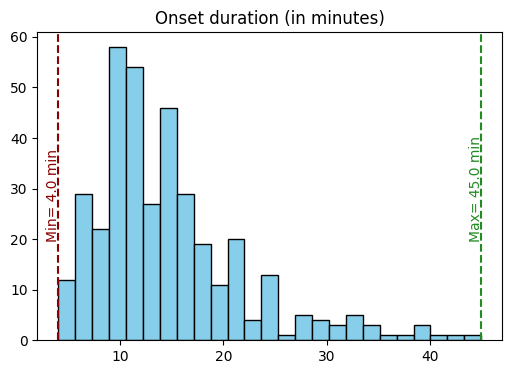

In [41]:
fig = plt.figure(figsize=(6, 4))
plt.hist(onset_duration, bins=25, edgecolor="k", facecolor="skyblue")
min_duration = min(onset_duration) 
max_duration = max(onset_duration) 
plt.axvline(x=min(onset_duration), ls="--", color="darkred")
plt.text(min_duration-1.2, 20, f"Min= {min_duration} min", rotation="vertical", color="darkred")
plt.axvline(x=max(onset_duration), ls="--", color="forestgreen")
plt.text(max_duration-1.2, 20, f"Max= {max_duration} min", rotation="vertical", color="forestgreen")
plt.title("Onset duration (in minutes)")

Text(0.5, 1.0, 'Decay duration (in minutes)')

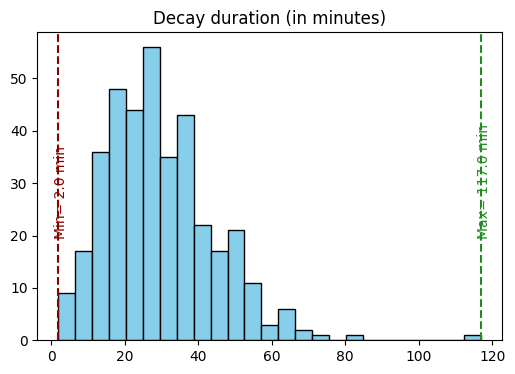

In [43]:
fig = plt.figure(figsize=(6, 4))
plt.hist(decay_duration, bins=25, edgecolor="k", facecolor="skyblue")
min_duration = min(decay_duration) 
max_duration = max(decay_duration) 
plt.axvline(x=min(decay_duration), ls="--", color="darkred")
plt.text(min_duration-1.2, 20, f"Min= {min_duration} min", rotation="vertical", color="darkred")
plt.axvline(x=max(decay_duration), ls="--", color="forestgreen")
plt.text(max_duration-1.2, 20, f"Max= {max_duration} min", rotation="vertical", color="forestgreen")
plt.title("Decay duration (in minutes)")

<Axes: ylabel='Frequency'>

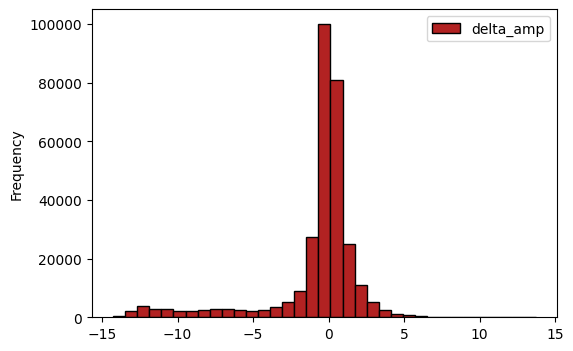

In [44]:
fig, ax = plt.subplots(figsize=(6,4))
# df_diurno[["delta_amp"]].plot(kind ="box", color="b", ax=ax,)
df_diurno[["delta_amp"]].plot(kind ="hist", color="firebrick", ax=ax,bins=35, edgecolor="k")


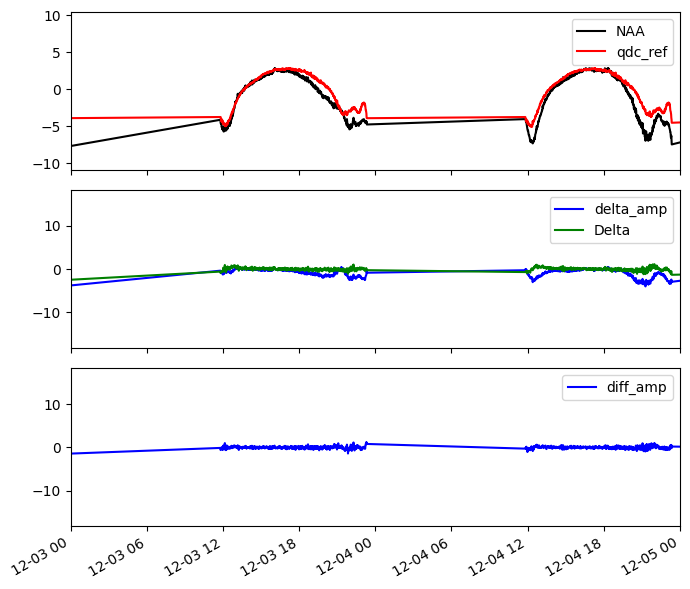

In [45]:

dl1, dl2 = dt.datetime(2025, 12, 3), dt.datetime(2025, 12, 5)

# 1. Creación de subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(7, 6
                                                   ), sharex=True)

# 2. Graficación de señales
df_diurno[["NAA", "qdc_ref"]].plot(color=["black", "red"], ax=ax1)
df_diurno[["delta_amp"]].plot(color=["blue"], ax=ax2)
df_diurno[["Delta"]].plot(color=["green"], ax=ax2)
df_diurno[["diff_amp"]].plot(color=["blue"], ax=ax3)

# 3. Mapeo de colores para cada estado {1, 2}
colores_estado = {
    1: ('red', 0.35, 'Onset (s=1)'),
    2: ('orange', 0.35, 'Decay (s=2)')
}

# 4. Aplicación de las bandas de color en todos los subplots
axes = [ax1, ax2, ax3]

for ax in axes:
    for estado, (color, alpha, label) in colores_estado.items():
        ax.fill_between(
            df_diurno.index, 0, 1,
            where=(df_diurno['state'] == estado),
            color=color, alpha=alpha,
            transform=ax.get_xaxis_transform(),
            step='mid'
        )

# Configuración final
ax1.set_xlim(dl1, dl2)
plt.tight_layout()
plt.show()

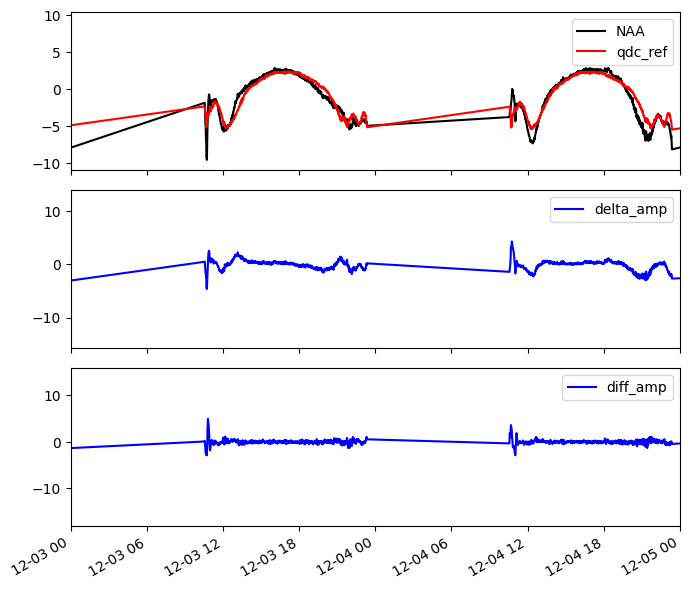

Features used: ['delta_amp', 'diff_amp']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...


         1 -693368.23981614             +nan
         2 -537680.91954947 +155687.32026666
         3 -372166.59517476 +165514.32437471
         4 -325114.64434873  +47051.95082603
         5 -322630.39120189   +2484.25314684
         6 -322236.53826575    +393.85293614
         7 -322146.32047852     +90.21778723
         8 -322122.60132590     +23.71915263
         9 -322115.52391102      +7.07741488
        10 -322113.32929040      +2.19462062
        11 -322112.65312884      +0.67616156
        12 -322112.44766841      +0.20546042
        13 -322112.38587919      +0.06178922
        14 -322112.36740822      +0.01847097


[OK] model Converged!

Transmat
model transmat A:
 [[0.97989283 0.02010717]
 [0.00531139 0.99468861]]

initial transmat
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]
True events:	 90
Predicted events:	 234

 ----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        41
           1       0.40      0.30      0.34        91

    accuracy                           0.20       132
   macro avg       0.20      0.15      0.17       132
weighted avg       0.27      0.20      0.23       132

Nueva Matriz de Confusión:
[[ 0 41]
 [64 27]]
Endr of the training & validation


        15 -322112.36190587      +0.00550235


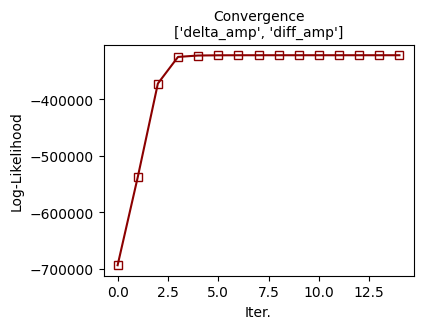

In [35]:
features = ["delta_amp", "diff_amp"]
print("Features used:", features)
X = df_diurno[features].values
y = df_diurno['state'].values # 0: Normal, 1: Rise, 2: Decay
t = df_diurno.index

split_idx = int(0.8 * len(X))
X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
X_test  = scaler.transform(X_test_raw)        # ONLY transform on test

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(X)
# # Cortamos al 80% del tiempo.
# split_idx = int(len(X_scaled) * 0.8)

# X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]
t_train, t_test = t[:split_idx], t[split_idx:]
X_train = np.nan_to_num(X_train, nan=0.0, posinf=10.0, neginf=-10.0)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")

# Usamos los datos de TRAIN para definir qué es cada estado.

def calculate_mean_and_cov(features, labels):
    unique_labels = np.unique(labels)
    n_states = len(unique_labels)
    n_features = features.shape[1]
    
    means = np.zeros((n_states, n_features))
    covars = np.zeros((n_states, n_features, n_features))
    
    for i, state in enumerate(unique_labels):
        state_data = features[labels == state]
        means[i] = np.mean(state_data, axis=0)
        cov = np.cov(state_data.T)
        min_covar = 1e-4  # Valor pequeño para darle "volumen" a la gaussiana
        cov = cov + np.eye(n_features) * min_covar
        
        cov = (cov + cov.T) / 2
        covars[i] = cov
        
    return means, covars


def calculate_startprob(labels):

    n_states = len(np.unique(labels))
    startprob = np.zeros(n_states)

    initial_state = int(labels[0])
    startprob[initial_state] = 1.0

    return startprob
    
def calculate_transmat(labels):

    n_states = len(np.unique(labels))
    transmat = np.zeros((n_states, n_states))

    # 1. Contar todas las transiciones en la secuencia
    for i in range(len(labels) - 1):
        from_state = int(labels[i])
        to_state = int(labels[i+1])
        transmat[from_state, to_state] += 1

    row_sums = transmat.sum(axis=1, keepdims=True)
    with np.errstate(divide='ignore', invalid='ignore'):
        transmat = np.where(row_sums > 0, transmat / row_sums, 0)
    return transmat

# 
startprob = calculate_startprob(y_train)
transmat = calculate_transmat(y_train)
means, covars = calculate_mean_and_cov(X_train, y_train)
print("Transition Matrix A:\n",transmat)

# init the model
model = hmm.GaussianHMM(
    n_components=2, 
    covariance_type="full", 
    # init_params="smc", # 
    init_params="",
    min_covar=1e-3, 
    n_iter=50,          # Le damos iteraciones para converger
    verbose=True
)

model.startprob_ = startprob
model.transmat_ = transmat
model.means_ = means
model.covars_ = covars

print("\nAfinando parámetros con algoritmo EM...")
model.fit(X_train)

if model.monitor_.converged:
# print("[OK] Model Successfully converged!" if model.monitor_.converged} else "[XX] Model Not connverged!")
    print("[OK] model Converged!")
    fig = plt.figure(figsize=(4,3))
    plt.plot( model.monitor_.history, "-s", color="darkred", markerfacecolor="none")
    #model.monitor_.n_iter
    plt.xlabel("Iter.")
    plt.ylabel("Log-Likelihood")
    plt.title(f"Convergence\n{features}", fontsize=10)
    
    print("\nTransmat\nmodel transmat A:\n", model.transmat_ )
    print("\ninitial transmat\n",transmat)
    y_pred = model.predict(X_test)
    # processing the predicted states: grab time intervals
    rise_pred_intervals     = mu.find_state_intervals(t_test, y_pred,target=1) 
    decay_pred_intervals    = mu.find_state_intervals(t_test, y_pred,target=2) 
    rise_true_intervals     = mu.find_state_intervals(t_test, y_test, target=1)
    decay_true_intervals    = mu.find_state_intervals(t_test, y_test, target=2)
    # validate rise s=1 match - rise_true_intervals
    matchdf_smooth = mu.validate_match(rise_true_intervals, rise_pred_intervals, df_diurno["delta_amp"], -3)
    print("\n", "--"*50)
    print(classification_report(matchdf_smooth["true"], matchdf_smooth["pred"]))
    print("Nueva Matriz de Confusión:")
    print(confusion_matrix(matchdf_smooth["true"], matchdf_smooth["pred"]))
    print("Endr of the training & validation")
else:
    print("[!!] model NOT Converged!\n-> End of the training.")


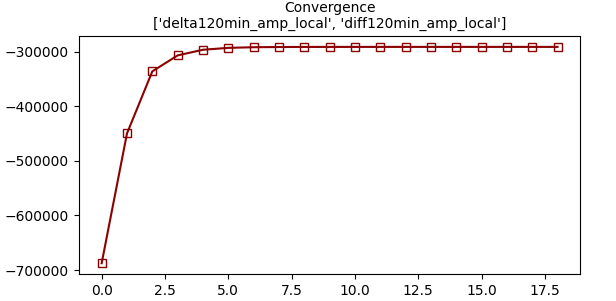

In [149]:
# fig = plt.figure()
# ax = plt.subplot(211)
# plt.plot(model.means_, label="means") 
# plt.legend()
# ax = plt.subplot(212)
# ax.plot(model.covars_, label="covars")
# ax.legend()

In [36]:
#prediction
y_pred = model.predict(X_test)

In [46]:
import importlib
importlib.reload(mu)

<module 'modelutils' from '/home/diace/notebooks/aldo/flare/modelutils.py'>

In [162]:
def filter_smooth_ypred(y_pred, t_pred, s, lower, upper):
    '''
    y_pred : predicted sequence of states array
    y_pred : time  array for the y_test array (equivalently for the y_pred)
    s      : target state
    lower/upper  : minmum/maximum duraton in minutes
    ---
    Returns: filtered y_pred º
    '''       
    _start, _end = state_regime_range(y_pred, t_pred, s)
    _td = (_end - _start)/np.timedelta64(1, "m") # time delta
    return y_pred[(lower <= _td) & (_td >= upper)]

def state_regime_range(s_arr, t_arr, s=1):
    '''
    s_arr  : sequence of states array
    t_arr  : time array
    s      : target state value
    ---
    Returns: t_start, t_end
    '''
    s_arr[-1] = 0 if s_arr[-1] == s else s_arr[-1] 
    mask_s_arr = s_arr==s
    diff_y = np.diff((mask_s_arr==s)/1) if  (s_arr[-1]!=s) else np.diff(np.pad(mask_s_arr, (0, 1), 'constant', constant_values=(0)))
    
    ti_end   = t_arr[np.pad(diff_y, (1, 0))==-1] # /1 because of the boolen in == and the following math operatins
    ti_start = t_arr[np.pad(diff_y, (1, 0))==1]
    # if  len(ti_start)-len(ti_end) == 1:
        
        
    # print(len(ti_end), len(ti_start))
    # s_duration_pred = ti_end - ti_start
    # return s_duration_pred.astype('timedelta64[s]')/np.timedelta64(60,"s" )
    # for l in zip(ti_end, ti_start):
        # print(l, (l[0]-l[1])/np.timedelta64(60,"s"))
    return ti_start, ti_end
    

### freeze the transmat


comments:
 
Gaussian HMM
3 estados: normal onset y decay
mismas componentes que ene le ytest de 2 estado

params      = mc
init_params =  


---

==== Trial 0 ==============
Features used: ['delta_amp', 'diff_amp']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]

Afinando parámetros con algoritmo EM...


         1 -667482.49236707             +nan
         2 -439984.55362769 +227497.93873937
         3 -315877.15393018 +124107.39969752
         4 -297277.22353348  +18599.93039669
         5 -289439.25250970   +7837.97102378
         6 -287808.69273112   +1630.55977859
         7 -287685.83563308    +122.85709804
         8 -287644.24533624     +41.59029684
         9 -287615.54540631     +28.69992994
        10 -287590.18747675     +25.35792956
        11 -287569.57518910     +20.61228765
        12 -287550.84927757     +18.72591153
        13 -287528.35199574     +22.49728184
        14 -287502.29224475     +26.05975099
        15 -287470.24790745     +32.04433730
        16 -287397.45555787     +72.79234959
        17 -287068.63294833    +328.82260954
        18 -284567.11242815   +2501.52052017
        19 -271559.00413313  +13008.10829503
        20 -261229.17696881  +10329.82716432
        21 -254300.88777214   +6928.28919667
        22 -248319.95352666   +5980.93424548
        23

[OK] model Converged!

Transmat
model transmat A:
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]

initial transmat
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]
True events:	 90
Predicted (raw) events:	 208

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        71
           1       0.11      0.10      0.11        90

    accuracy                           0.06       161
   macro avg       0.06      0.05      0.05       161
weighted avg       0.06      0.06      0.06       161

Nueva Matriz de Confusión:
[[ 0 71]
 [81  9]]

==== Trial 1 ==============
Features used: ['delta120min_amp_local', 'diff120min_amp_local']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[9.9898

         1 -680976.98877168             +nan
         2 -528950.10467218 +152026.88409949
         3 -453004.64283330  +75945.46183888
         4 -419164.61153956  +33840.03129374
         5 -403760.74490809  +15403.86663148
         6 -395429.95707370   +8330.78783439
         7 -390742.27081339   +4687.68626030
         8 -388010.87070447   +2731.40010892
         9 -386335.65611227   +1675.21459220
        10 -385146.15758761   +1189.49852466
        11 -384271.03761773    +875.11996988
        12 -383685.36269362    +585.67492411
        13 -383202.86709967    +482.49559395
        14 -382789.57915471    +413.28794495
        15 -382453.25152774    +336.32762697
        16 -382170.40747268    +282.84405506
        17 -381938.10316895    +232.30430372
        18 -381780.28593386    +157.81723509
        19 -381679.42307739    +100.86285648
        20 -381617.29412116     +62.12895623
        21 -381575.73791949     +41.55620167
        22 -381537.78665122     +37.95126827
        23

[OK] model Converged!

Transmat
model transmat A:
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]

initial transmat
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]
True events:	 90
Predicted (raw) events:	 338

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        55
           1       0.34      0.31      0.32        90

    accuracy                           0.19       145
   macro avg       0.17      0.16      0.16       145
weighted avg       0.21      0.19      0.20       145

Nueva Matriz de Confusión:
[[ 0 55]
 [62 28]]

==== Trial 2 ==============
Features used: ['delta120min_amp_local', 'diff120min_amp_local', 'transient_120']
Train samples: 273007 | Test samples: 68252
Transition Ma

...

[OK] model Converged!

Transmat
model transmat A:
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]

initial transmat
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]
True events:	 90
Predicted (raw) events:	 418

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       155
           1       0.20      0.42      0.27        90

    accuracy                           0.16       245
   macro avg       0.10      0.21      0.13       245
weighted avg       0.07      0.16      0.10       245

Nueva Matriz de Confusión:
[[  0 155]
 [ 52  38]]

==== Trial 4 ==============
Features used: ['transient_60']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[9.98989868e-01 1.01013205e-03 0.000

         1 -311960.34730156             +nan
         2 -178097.34612255 +133863.00117901
         3 -153018.67494060  +25078.67118194
         4 -143019.32074903   +9999.35419157
         5 -137949.93890564   +5069.38184339
         6 -135291.16360633   +2658.77529931
         7 -133875.02711906   +1416.13648727
         8 -133040.53962548    +834.48749358
         9 -132445.46284442    +595.07678106
        10 -132001.06914013    +444.39370429
        11 -131656.07614464    +344.99299548
        12 -131424.58419434    +231.49195030
        13 -131269.46561443    +155.11857991
        14 -131155.38786717    +114.07774726
        15 -131074.85867255     +80.52919462
        16 -131021.04192823     +53.81674432
        17 -130983.99009122     +37.05183701
        18 -130957.57633044     +26.41376078
        19 -130938.31556324     +19.26076720
        20 -130923.76899916     +14.54656408
        21 -130912.23438004     +11.53461912
        22 -130902.54144408      +9.69293596
        23

[OK] model Converged!

Transmat
model transmat A:
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]

initial transmat
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]
True events:	 90
Predicted (raw) events:	 476

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       201
           1       0.17      0.47      0.25        90

    accuracy                           0.14       291
   macro avg       0.09      0.23      0.13       291
weighted avg       0.05      0.14      0.08       291

Nueva Matriz de Confusión:
[[  0 201]
 [ 48  42]]

==== Trial 5 ==============
Features used: ['transient_120']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[9.98989868e-01 1.01013205e-03 0.00

         1 -328202.03285224             +nan
         2 -213411.16096106 +114790.87189118
         3 -170145.49547151  +43265.66548955
         4 -155266.59056665  +14878.90490486
         5 -149280.18188806   +5986.40867859
         6 -146646.39808666   +2633.78380140
         7 -145565.39154938   +1081.00653728
         8 -144980.72440377    +584.66714561
         9 -144621.65875634    +359.06564743
        10 -144428.14027099    +193.51848535
        11 -144318.06764248    +110.07262851
        12 -144240.20032198     +77.86732050
        13 -144168.79949329     +71.40082869
        14 -144105.12727097     +63.67222232
        15 -144053.11998655     +52.00728443
        16 -144012.20682526     +40.91316128
        17 -143979.84293984     +32.36388542
        18 -143952.40244493     +27.44049491
        19 -143928.83930305     +23.56314189
        20 -143909.59851021     +19.24079284
        21 -143894.62034235     +14.97816786
        22 -143883.09369899     +11.52664336
        23

[OK] model Converged!

Transmat
model transmat A:
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]

initial transmat
 [[9.98989868e-01 1.01013205e-03 0.00000000e+00]
 [2.34411627e-04 9.34130333e-01 6.56352555e-02]
 [3.12723800e-02 2.14848413e-03 9.66579136e-01]]
True events:	 90
Predicted (raw) events:	 437

 --------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       162
           1       0.14      0.30      0.19        90

    accuracy                           0.11       252
   macro avg       0.07      0.15      0.10       252
weighted avg       0.05      0.11      0.07       252

Nueva Matriz de Confusión:
[[  0 162]
 [ 63  27]]

End of the training & validation


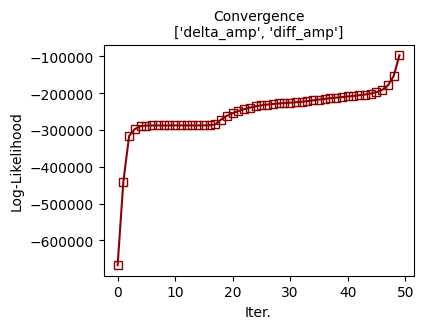

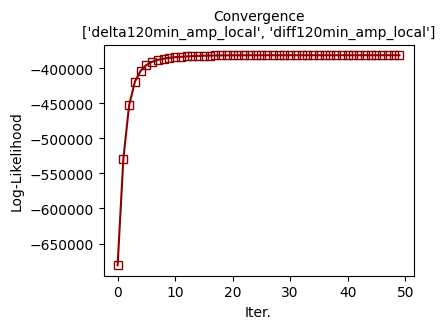

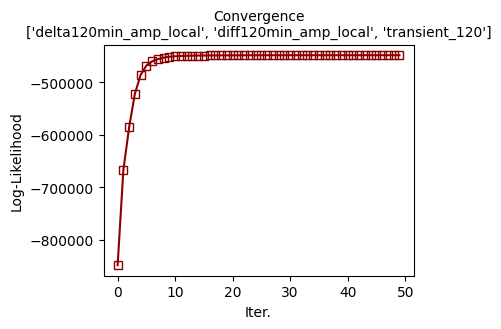

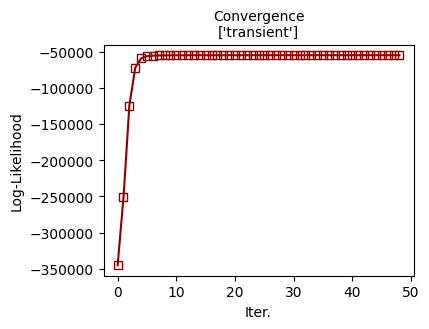

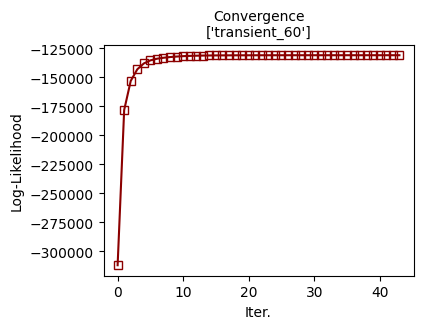

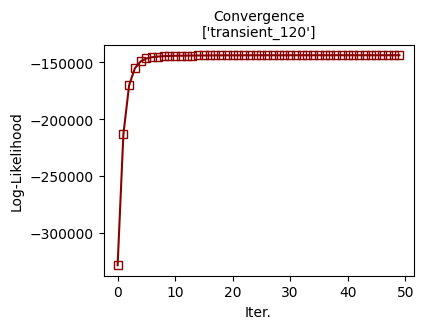

In [47]:

#%%capture captured_outtext --no-stderr

params      = "mc"
init_params = ""

comments= f'''
Gaussian HMM
3 estados: normal onset y decay
mismas componentes que ene le ytest de 2 estado

params      = {params}
init_params = {init_params} 

'''
print("comments:\n", comments)
print("---")

listoffeatures = [
    ["delta_amp", "diff_amp"], 
    ["delta120min_amp_local", "diff120min_amp_local"], 
    ["delta120min_amp_local", "diff120min_amp_local", "transient_120"],
    [ "transient"],
    ["transient_60"],
    ["transient_120"]
]

n_trial = 0
for k, lf in enumerate(listoffeatures):
    print(f"\n==== Trial {k} ==============" )
    features = lf
    print("Features used:", features)
    X = df_diurno[features].values
    y = df_diurno['state'].values # 0: Normal, 1: Rise, 2: Decay
    t = df_diurno.index
    
    split_idx = int(0.8 * len(X))
    X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
    X_test  = scaler.transform(X_test_raw)        # ONLY transform on test
    
    # scaler = StandardScaler()
    # X_scaled = scaler.fit_transform(X)
    # # Cortamos al 80% del tiempo.
    # split_idx = int(len(X_scaled) * 0.8)
    
    # X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    t_train, t_test = t[:split_idx], t[split_idx:]
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=10.0, neginf=-10.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
    print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
    
    # 
    startprob = mu.calculate_startprob(y_train)
    transmat = mu.calculate_transmat(y_train)
    means, covars = mu.calculate_mean_and_cov(X_train, y_train)
    print("Transition Matrix A:\n",transmat)
    
    # init the model
    model = hmm.GaussianHMM(
        n_components=3,
        covariance_type="full",
        init_params="",
        params=params,          # <-- freeze startprob AND transmat
        min_covar=1e-3,
        n_iter=50,
        verbose=True,
    )
    model.startprob_ = startprob
    model.transmat_ = transmat
    model.means_    = means
    model.covars_   = covars
    
    print("\nAfinando parámetros con algoritmo EM...")
    model.fit(X_train)
    
    if model.monitor_.converged:
    # print("[OK] Model Successfully converged!" if model.monitor_.converged} else "[XX] Model Not connverged!")
        print("[OK] model Converged!")
        fig = plt.figure(figsize=(4,3))
        plt.plot( model.monitor_.history, "-s", color="darkred", markerfacecolor="none")
        #model.monitor_.n_iter
        plt.xlabel("Iter.")
        plt.ylabel("Log-Likelihood")
        plt.title(f"Convergence\n{features}", fontsize=10)
        
        print("\nTransmat\nmodel transmat A:\n", model.transmat_ )
        print("\ninitial transmat\n",transmat)
        y_pred = model.predict(X_test)
        # y_pred  = filter_smooth_ypred(_y_pred, t_test, 1 ,4,120)
        # processing the predicted states: grab time intervals
        rise_pred_intervals     = mu.find_state_intervals(t_test, y_pred,target=1) 
        decay_pred_intervals    = mu.find_state_intervals(t_test, y_pred,target=2) 
        rise_true_intervals     = mu.find_state_intervals(t_test, y_test, target=1)
        decay_true_intervals    = mu.find_state_intervals(t_test, y_test, target=2)
        # validate rise s=1 match - rise_true_intervals
        matchdf_smooth = mu.validate_match(rise_true_intervals, rise_pred_intervals, df_diurno["delta_amp"], -3)
        print("\n", "-"*50)
        print(classification_report(matchdf_smooth["true"], matchdf_smooth["pred"]))
        print("Nueva Matriz de Confusión:")
        print(confusion_matrix(matchdf_smooth["true"], matchdf_smooth["pred"]))
        
    else:
        print("[!!] model NOT Converged!\n-> End of the training.")

print("\n","="*50, "\nEnd of the training & validation")


In [56]:
aout = captured_outtext.stdout
print(aout)

comments:
 
se ha implementado un filtro para eliminar predicciones de muy corta duracion (por debajo del minimo observado en los datos=4min)
seha implementado el trasient tmado desde delta120min_amp_local en vez de usar el delta_amp usando qtc

params="mc"

---

==== Trial 0 ==============
Features used: ['delta_amp', 'diff_amp']
Train samples: 273007 | Test samples: 68252
Transition Matrix A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

Afinando parámetros con algoritmo EM...
[OK] model Converged!

Transmat
model transmat A:
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]

initial transmat
 [[0.99895438 0.00104562]
 [0.06586967 0.93413033]]
True events:	 90
Predicted events:	 0

 ----------------------------------------------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00      90.0

    accuracy                    

In [25]:
with open("train_fixedA_params-mc_alignright.txt", "w") as f:
    f.write(captured_outtext.stdout)

In [96]:
onset_duration_pred = t_test[np.pad(np.diff(y_pred),(1, 0))==-1] - t_test[np.pad(np.diff(y_pred),(1, 0))==1]
onset_duration_pred = onset_duration_pred.astype('timedelta64[s]')/np.timedelta64(60,"s" )
sum(onset_duration_pred<4)

np.int64(9)

In [ ]:
t_arr = t_test
s_arr = y_pre
s_duration_pred = t_arr[np.pad(np.diff(s_arr==s),(1, 0))==-1] - t_arr[np.pad(np.diff(s_arr==s),(1, 0))==1]
dd = s_duration_pred.astype('timedelta64[s]')/np.timedelta64(60,"s" )


In [63]:
_y_pred, y_pred

(array([0, 1, 1, ..., 0, 0, 0], shape=(68252,)), array([], dtype=int64))

In [105]:
ts  = t_test[np.pad(np.diff(y_pred),(1, 0))==1]
print("----1\n", ts[onset_duration_pred==1])
print("----2\n", ts[onset_duration_pred==2])
print("----3\n", ts[onset_duration_pred==3])

----1
 DatetimeIndex(['2026-01-06 15:48:00', '2026-02-17 23:05:00',
               '2026-02-18 18:47:00', '2026-02-20 22:25:00',
               '2026-03-04 14:39:00', '2026-04-07 19:45:00'],
              dtype='datetime64[ns]', freq=None)
----2
 DatetimeIndex(['2026-03-16 18:39:00'], dtype='datetime64[ns]', freq=None)
----3
 DatetimeIndex(['2026-03-28 15:49:00', '2026-04-06 21:38:00'], dtype='datetime64[ns]', freq=None)


Text(0.5, 1.0, 'Onset duration (in minutes)')

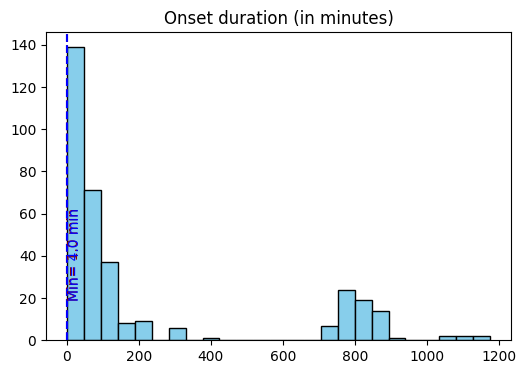

In [100]:
fig = plt.figure(figsize=(6, 4))
plt.hist(onset_duration_pred, bins=25, edgecolor="k", facecolor="skyblue")
min_duration_pred = min(onset_duration_pred) 
plt.axvline(x=min(onset_duration_pred), ls="--", color="darkred")
plt.text(min_duration_pred-1.2, 20, f"Min= {min_duration_pred} min", rotation="vertical", color="darkred")

# min duration true
plt.axvline(x=min(onset_duration), ls="--", color="blue")
plt.text(min_duration-1.2, 20, f"Min= {min_duration} min", rotation="vertical", color="blue")
plt.title("Onset duration (in minutes)")
# plt.xscale("log")#

In [58]:
dl = [
    dt.datetime(2026, 1,1),
    dt.datetime(2026, 4, 10)
    ]

fig, axs = plt.subplots(2,1,sharex=True)
ax0 = axs[0]

#ax0.plot(t_test, X_test[:,0], color="gray", lw=1,label="Signal")
#ax0.plot(t_test, X_test[:,1], color="blue", lw=1, label="Diff. Signal")
ax0.plot(df["NAA"].loc[dl[0]:dl[1]], color="black", lw=1, label="Signal raw")
ax0.plot(df_diurno["delta_amp"].loc[dl[0]:dl[1]], color="navy", lw=1, label="Delta-amp")
ax1 = ax0.twinx()
testmask = (dl[0]<t_test) & (t_test<dl[1])
ax1.plot(t_test[testmask], y_test[testmask], color="red", ls="--", lw=1.5, label="True state")
for t1,t2 in zip(matchdf_smooth["t_pred_1"], matchdf_smooth["t_pred_2"]):
    if not pd.isna(t1):
        ax1.axvspan(t1,t2, color="yellowgreen",alpha=0.6, label="Predicted event")
#plt.legend(l,"Predicted event")
ax0.set_ylabel("Amp. (dB)")

ax0.legend()
ax1.set_ylabel("State")
ax2 = axs[1]
ax2.plot(df['GOES18'].loc[dl[0]:dl[1]], color="purple",label="X rays GOES")
ax2.set_ylabel("Flux (W/m²)")
ax2.set_yscale("log")
ax2.set_xlabel("Time UT")
fig.autofmt_xdate()

In [57]:
plt.close()

In [60]:
print("true events", sum(np.diff(y_test==1) > 0))
print("pred events", sum(np.diff(y_pred==1) > 0))

true events 180
pred events 480


In [48]:
matchdf_smooth

,t_true_1,t_true_2,t_pred_1,t_pred_2,true,pred
0,NaT,NaT,2026-01-04 13:25:00,2026-01-04 13:28:00,0,1
1,NaT,NaT,2026-01-04 21:40:00,2026-01-04 21:46:00,0,1
2,NaT,NaT,2026-01-04 22:28:00,2026-01-04 22:31:00,0,1
3,NaT,NaT,2026-01-05 23:31:00,2026-01-06 12:07:00,0,1
4,NaT,NaT,2026-01-06 12:50:00,2026-01-06 12:53:00,0,1
...,...,...,...,...,...,...
372,NaT,NaT,2026-04-06 19:39:00,2026-04-06 19:42:00,0,1
373,NaT,NaT,2026-04-06 19:44:00,2026-04-06 19:47:00,0,1
374,NaT,NaT,2026-04-06 21:38:00,2026-04-06 21:58:00,0,1
375,NaT,NaT,2026-04-06 22:51:00,2026-04-06 22:58:00,0,1


In [57]:
plt.figure()
plt.plot(t_train, X_train)
plt.legend()

/tmp/ipykernel_8846/1644147617.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


In [111]:
%matplotlib qt
plt.figure()
ax = plt.subplot()
ax.plot(t_test, df_diurno.loc[t_test, "NAA"], color="black")
ax2 = ax.twinx()
ax2.plot(t_test,y_test, color="forestgreen", alpha=0.75)
ax2.plot(t_test,y_pred, color="red", alpha=0.7)

plt.show()

## Gaussian Mixture


In [51]:
%%capture captured_outtext --no-stderr
N_MIX       = 3
params      = "mc"
init_params = ""

comments= f'''
GMM-HMM
3 estados
params      = {params}
init_params = {init_params} 
NMIX        = {N_MIX}
'''
print("comments:\n", comments)
print("---")

listoffeatures = [
    ["delta_amp", "diff_amp"], 
    ["delta120min_amp_local", "diff120min_amp_local"], 
    ["delta120min_amp_local", "diff120min_amp_local", "transient_120"],
    [ "transient"],
    ["transient_60"],
    ["transient_120"]
]

n_trial = 0
for k, lf in enumerate(listoffeatures):
    print(f"\n==== Trial {k} ==============" )
    features = lf
    print("Features used:", features)
    X = df_diurno[features].values
    y = df_diurno['state'].values # 0: Normal, 1: Rise, 2: Decay
    t = df_diurno.index
    
    split_idx = int(0.8 * len(X))
    X_train_raw, X_test_raw = X[:split_idx], X[split_idx:]
    
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)   # fit + transform on train
    X_test  = scaler.transform(X_test_raw)        # ONLY transform on test
    
    # scaler = StandardScaler()
    # X_scaled = scaler.fit_transform(X)
    # # Cortamos al 80% del tiempo.
    # split_idx = int(len(X_scaled) * 0.8)
    
    # X_train, X_test = X_scaled[:split_idx], X_scaled[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]
    t_train, t_test = t[:split_idx], t[split_idx:]
    X_train = np.nan_to_num(X_train, nan=0.0, posinf=10.0, neginf=-10.0)
    X_test = np.nan_to_num(X_test, nan=0.0, posinf=10.0, neginf=-10.0)
    print(f"Train samples: {len(X_train)} | Test samples: {len(X_test)}")
    
    # 
    startprob = mu.calculate_startprob(y_train)
    transmat = mu.calculate_transmat(y_train)
    # means, covars = mu.calculate_mean_and_cov(X_train, y_train) # used for Gaussian
    means, covars, weights = mu.gmm_init_from_labels(X_train, y_train, n_mix=N_MIX, min_covar=1e-3,n_states=3)
    print("Transition Matrix A:\n",transmat)
    
    # init the model
    # model = hmm.GaussianHMM(
    #     n_components=2,
    #     covariance_type="full",
    #     init_params="",
    #     params="mc",          # <-- freeze startprob AND transmat
    #     min_covar=1e-3,
    #     n_iter=50,
    #     verbose=True,
    # )
    model = hmm.GMMHMM(
        n_components=3,
        n_mix=N_MIX,
        covariance_type= "diag",
        init_params=init_params,
        params=params,          # <-- freeze startprob AND transmat
        min_covar=1e-3,
        n_iter=100,
        verbose=True,
    )

    model.startprob_ = startprob
    model.transmat_  = transmat
    model.means_     = means
    model.covars_    = covars
    model.weights_   = weights
    
    print("\nAfinando parámetros con algoritmo EM...")
    model.fit(X_train)
    
    if model.monitor_.converged:
    # print("[OK] Model Successfully converged!" if model.monitor_.converged} else "[XX] Model Not connverged!")
        print("[OK] model Converged!")
        fig = plt.figure(figsize=(4,3))
        plt.plot( model.monitor_.history, "-s", color="darkred", markerfacecolor="none")
        #model.monitor_.n_iter
        plt.xlabel("Iter.")
        plt.ylabel("Log-Likelihood")
        plt.title(f"Convergence\n{features}", fontsize=10)
        
        print("\nTransmat\nmodel transmat A:\n", model.transmat_ )
        print("\ninitial transmat\n",transmat)
        y_pred = model.predict(X_test)
        # y_pred  = filter_smooth_ypred(_y_pred, t_test, 1 ,4,120)
        # processing the predicted states: grab time intervals
        rise_pred_intervals     = mu.find_state_intervals(t_test, y_pred,target=1) 
        decay_pred_intervals    = mu.find_state_intervals(t_test, y_pred,target=2) 
        rise_true_intervals     = mu.find_state_intervals(t_test, y_test, target=1)
        decay_true_intervals    = mu.find_state_intervals(t_test, y_test, target=2)
        # validate rise s=1 match - rise_true_intervals
        matchdf_smooth = mu.validate_match(rise_true_intervals, rise_pred_intervals, df_diurno["delta_amp"], -3)
        print("\n", "-"*50)
        print(classification_report(matchdf_smooth["true"], matchdf_smooth["pred"]))
        print("Nueva Matriz de Confusión:")
        print(confusion_matrix(matchdf_smooth["true"], matchdf_smooth["pred"]))
        
    else:
        print("[!!] model NOT Converged!\n-> End of the training.")

print("\n","="*50, "\nEnd of the training & validation")


         1 -665558.72701776             +nan
         2 -426253.92330766 +239304.80371010
         3 -323449.93523987 +102803.98806779
         4 -302079.87566310  +21370.05957677
         5 -292024.51765696  +10055.35800614
         6 -277062.12899200  +14962.38866496
         7 -265964.37468089  +11097.75431112
         8 -257413.32957974   +8551.04510115
         9 -251399.77297349   +6013.55660624
        10 -246966.34435659   +4433.42861690
        11 -242765.51153960   +4200.83281699
        12 -237577.21826619   +5188.29327341
        13 -231189.29036383   +6387.92790237
        14 -224402.36663096   +6786.92373287
        15 -217406.07470817   +6996.29192279
        16 -210931.52254603   +6474.55216214
        17 -203743.89747212   +7187.62507391
        18 -197464.53562466   +6279.36184747
        19 -190746.04252004   +6718.49310461
        20 -182682.98238751   +8063.06013254
        21 -172829.33845869   +9853.64392882
        22 -159932.58419201  +12896.75426668
        23